<a href="https://colab.research.google.com/github/Priya9823/Dublin-Airbnb-Market-Analysis/blob/main/youtube.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas
import pandas as pd
rising = pd.read_csv("/content/drive/MyDrive/projects1/searched_with_rising-queries_IE_20250520-0205_20260520-0205.csv")
TOP = pd.read_csv("/content/drive/MyDrive/projects1/searched_with_top-queries_IE_20250520-0205_20260520-0205.csv")
Timings = pd.read_csv("/content/drive/MyDrive/projects1/time_series_IE_20250520-0204_20260520-0204.csv")

In [3]:
rising = rising.reset_index(drop = True)
TOP.head()

,query,search interest,increase percent
0,youtube youtube,100,2%
1,youtube,97,2%
2,on youtube,22,9%
3,youtube channel,11,-10%
4,shorts,8,20%


In [4]:
rising.head()

,query,search interest,increase percent
0,preston journalist,0,Breakout
1,scott ritter youtube,0,Breakout
2,dalscone farm youtube,0,Breakout
3,silver fox hot takes youtube,0,"2,450%"
4,youtube wrapped,0,300%


In [5]:
rising = rising.rename(columns =
 {'query' : 'Query',
  'search interest':'Serach_Intrest',
  'increase percent' : 'Increase_percent' })
print(rising.columns)
TOP = TOP.rename(columns={'query':'query','search interest':'search_interest',
                          'increase percent':'increase_percent'})
TOP.columns

Index(['Query', 'Serach_Intrest', 'Increase_percent'], dtype='object')


Index(['query', 'search_interest', 'increase_percent'], dtype='object')

In [6]:
rising = rising.dropna(subset=['Serach_Intrest'])
rising = rising[rising['Serach_Intrest'] > 0]

In [7]:
rising.shape
rising.head()

,Query,Serach_Intrest,Increase_percent
15,tg4 youtube,1,70%
23,free movies on youtube full movies,3,60%
25,youtube free movies,5,40%
26,free movies on youtube,4,40%
29,films on youtube,1,40%


In [8]:
rising = rising.reset_index(drop = True )

In [9]:
rising.head()

,Query,Serach_Intrest,Increase_percent
0,tg4 youtube,1,70%
1,free movies on youtube full movies,3,60%
2,youtube free movies,5,40%
3,free movies on youtube,4,40%
4,films on youtube,1,40%


In [10]:
def top_serach(Query):
 r = rising[rising['Query'].str.contains(Query)]
 r = r.sort_values('Serach_Intrest', ascending = False)
 return r
 print(r)
top_serach('movies')
top_serach('films')

,Query,Serach_Intrest,Increase_percent
4,films on youtube,1,40%
5,youtube films,1,40%


In [11]:
top_ten = rising.sort_values('Serach_Intrest',ascending = False).head(10)
print(top_ten)

                                 Query  Serach_Intrest Increase_percent
8                               shorts               8              20%
11                      youtube movies               7              20%
2                  youtube free movies               5              40%
6                    movies on youtube               5              30%
7                          free movies               4              30%
3               free movies on youtube               4              40%
12                        kids youtube               4              20%
10                                  yt               4              20%
13                        youtube kids               4              20%
1   free movies on youtube full movies               3              60%


In [12]:
Timings.describe()

,YouTube
count,53.000000
mean,85.603774
std,7.365041
min,66.000000
25%,83.000000
50%,85.000000
75%,91.000000
max,100.000000


In [13]:
TOP.head()

,query,search_interest,increase_percent
0,youtube youtube,100,2%
1,youtube,97,2%
2,on youtube,22,9%
3,youtube channel,11,-10%
4,shorts,8,20%


In [14]:
TOP = TOP.dropna(subset=['search_interest'])
TOP = TOP[TOP['search_interest'] > 0]
TOP.head()

,query,search_interest,increase_percent
0,youtube youtube,100,2%
1,youtube,97,2%
2,on youtube,22,9%
3,youtube channel,11,-10%
4,shorts,8,20%


In [15]:
TOP = TOP.sort_values('search_interest',ascending = False)
top_50 = TOP.head(10)

In [16]:
!pip install matplotlib
import matplotlib.pyplot as plt


In [33]:
top_50['increase_percent'] = top_50['increase_percent'].str.replace('%', '').astype(float)
top_50 = top_50.sort_values('increase_percent', ascending= False)
top_50.head()

,query,search_interest,increase_percent
8,movies on youtube,5,30.0
4,shorts,8,20.0
6,youtube movies,7,20.0
9,youtube videos,5,10.0
2,on youtube,22,9.0


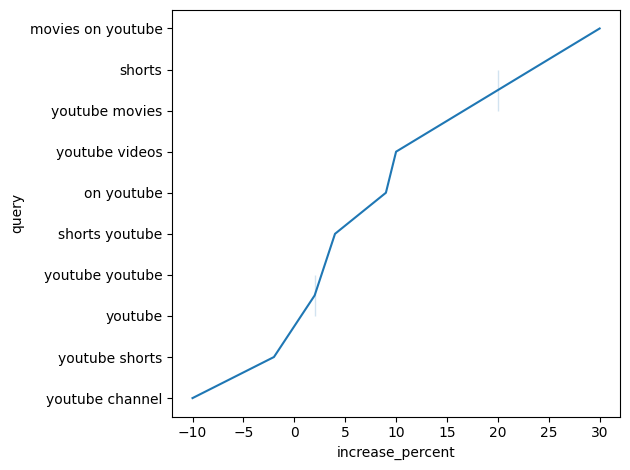

In [34]:
!pip install seaborn
top_50 = top_50.sort_values('increase_percent', ascending= False)
import seaborn as sns
sns.lineplot(data=top_50, x='increase_percent', y='query')
plt.tight_layout()
plt.show()

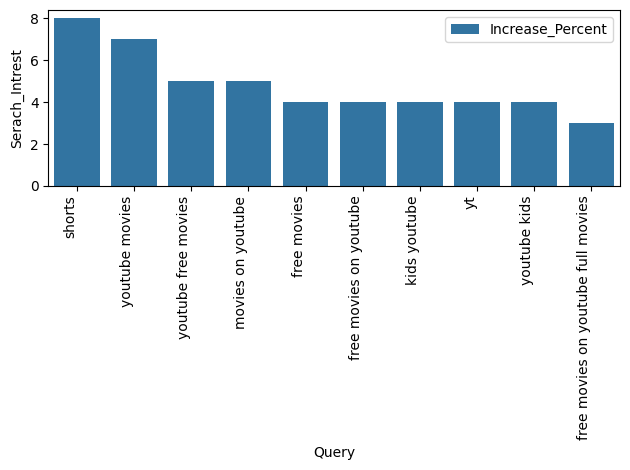

In [18]:
sns.barplot(data=top_ten, x='Query', y='Serach_Intrest', label='Increase_Percent')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

In [28]:
Timings.index = pd.to_datetime(Timings.index)

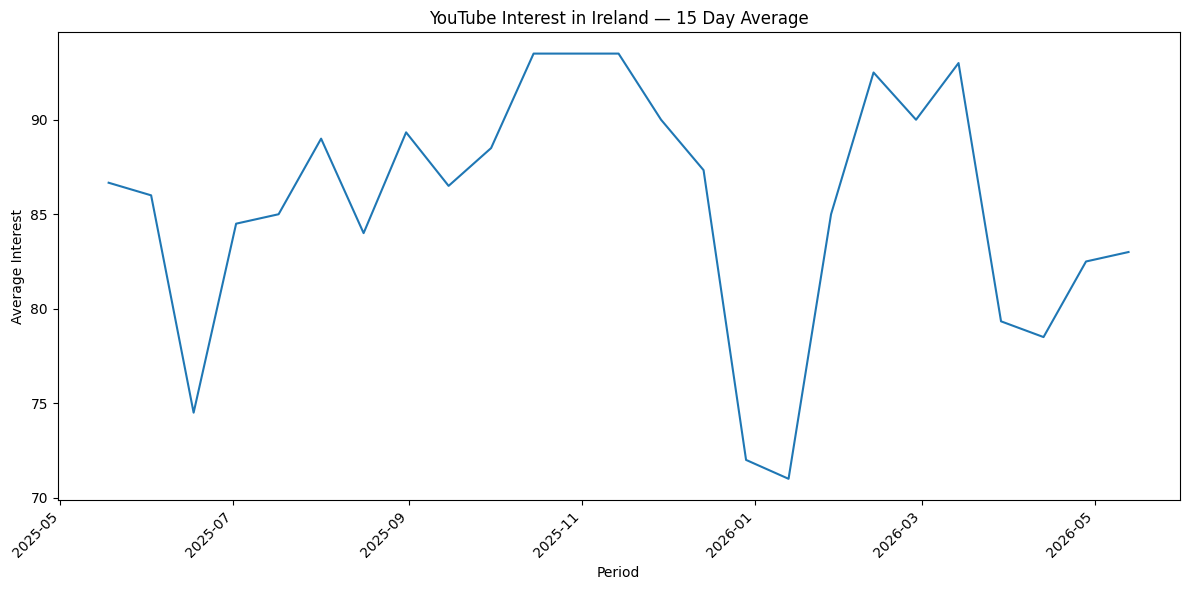

In [29]:
Timings_15day = Timings.resample('15D').mean()

plt.figure(figsize=(12, 6))
plt.plot(Timings_15day.index, Timings_15day['YouTube'])
plt.title('YouTube Interest in Ireland — 15 Day Average')
plt.xlabel('Period')
plt.ylabel('Average Interest')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
q4 = Timings['2025-10-01':'2025-12-31']
q1 = Timings['2026-01-01':'2026-03-31']

print("Q4 2025 average:", q4['YouTube'].mean().round(1))
print("Q1 2026 average:", q1['YouTube'].mean().round(1))
print("Drop:", (q4['YouTube'].mean() - q1['YouTube'].mean()).round(1))

Q4 2025 average: 90.8
Q1 2026 average: 84.2
Drop: 6.6


YouTube interest in Ireland averaged 90.8 in Q4 2025 but declined to 84.2 in Q1 2026, a drop of 6.6 points. Analysis suggests this dip is seasonal, coinciding with the Christmas and New Year period. To maintain engagement, we recommend promoting seasonal content such as Christmas music, festive playlists and holiday films on YouTube during November and December to sustain interest through the holiday period